In [1]:
import torch
import torch.nn as nn

In [2]:
# 对比损失（Contrastive Loss）
loss = nn.TripletMarginLoss(margin=1, p=2)
# 定义数据样本
a = torch.randn(100, 5, requires_grad=True)
p = torch.randn(100, 5, requires_grad=True)
n = torch.randn(100, 5, requires_grad=True)

In [ ]:
# 对比损失 人脸识别loss使用最多
loss_value = loss(a, p, n)
print(loss_value)

In [4]:
import numpy as np


# 椒盐噪声，传入原图像和引入噪声点比例
def pepper_salt(img, percentage):
    noise_img = img.copy()
    # 按比例计算噪点个数
    noise_num = int(percentage * img.shape[0] * img.shape[1])
    for i in range(noise_num):
        # 随机生成噪点坐标
        randx = np.random.randint(0, img.shape[0] - 1)
        randy = np.random.randint(0, img.shape[1] - 1)
        # 均匀生成黑白噪点
        if np.random.rand() < 0.5:
            noise_img[randx, randy] = 0
        else:
            noise_img[randx, randy] = 255
    return noise_img

In [5]:
import matplotlib.pyplot as plt
from PIL import Image  # 图像加载工具
import torchvision.transforms as transforms  # 图像预处理

In [6]:
# 一、加载数据
# 1. 加载图片
img_path = "Apple.jpg"
img = Image.open(img_path)

# 2. 定义并应用转换操作
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])
img_tensor = transform(img)
print(img_tensor.shape)

torch.Size([3, 256, 256])


In [7]:
# 3. 将张量转换为numpy数组
img_ndarray = img_tensor.numpy().transpose((1, 2, 0))
print(img_ndarray.shape)

(256, 256, 3)


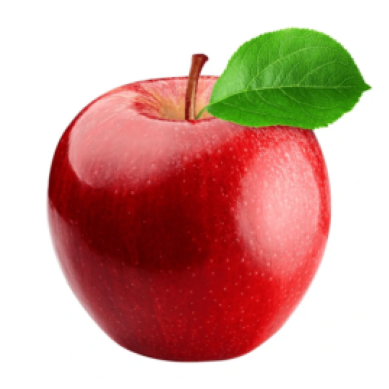

In [8]:
# 5. 用matplotlib显示图片
plt.imshow(img_ndarray)
plt.axis('off')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


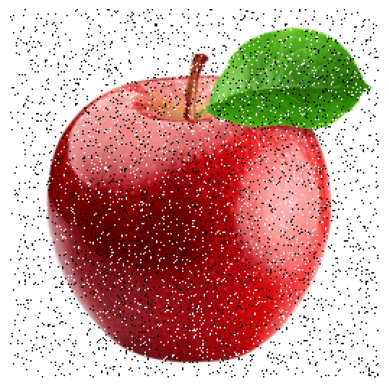

In [12]:
# 加入椒盐噪声
plt.imshow(pepper_salt(img_ndarray, 0.1))
plt.axis('off')
plt.show()

In [15]:
import torchvision.models as models

# 使用VGG16作为损失网络，计算感知损失
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [16]:
vgg_features = model.features.eval()
print(vgg_features)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [17]:
# 截取0~8层作为损失网络
loss_net = nn.Sequential(*list(vgg_features.children())[:9])
print(loss_net)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
)


In [18]:
# 定义数据
x = torch.randn(1, 3, 256, 256)
y = torch.randn(1, 3, 256, 256)
# 前向传播，得到特征向量
feature_x = loss_net(x)
feature_y = loss_net(y)
print(feature_x.shape, feature_y.shape)

torch.Size([1, 128, 128, 128]) torch.Size([1, 128, 128, 128])


In [19]:
# 计算损失
loss = nn.MSELoss()
loss_value = loss(feature_x, feature_y)
print(loss_value)

tensor(23.2956, grad_fn=<MseLossBackward0>)
